Importing and Loading Training data

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import joblib

# Load dataset
df = pd.read_csv("../data/coupon_data/train.csv")

print(df.shape)
df.head()


(78369, 5)


,id,campaign_id,coupon_id,customer_id,redemption_status
0,1,13,27,1053,0
1,2,13,116,48,0
2,6,9,635,205,0
3,7,13,644,1050,0
4,9,8,1017,1489,0


In [27]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78369 entries, 0 to 78368
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 78369 non-null  int64
 1   campaign_id        78369 non-null  int64
 2   coupon_id          78369 non-null  int64
 3   customer_id        78369 non-null  int64
 4   redemption_status  78369 non-null  int64
dtypes: int64(5)
memory usage: 3.0 MB


,id,campaign_id,coupon_id,customer_id,redemption_status
0,1,13,27,1053,0
1,2,13,116,48,0
2,6,9,635,205,0
3,7,13,644,1050,0
4,9,8,1017,1489,0


Data preprocessing

In [28]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=['redemption_status', 'id'])  # drop id since it's just row index
y = df['redemption_status']

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)


Train shape: (62695, 3) Val shape: (15674, 3)


Model Training with Class Balancing

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# 1. Logistic Regression (with class_weight balanced)
log_reg_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg_bal.fit(X_train, y_train)

# 2. Random Forest (with class_weight balanced)
rf_bal = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_bal.fit(X_train, y_train)

# 3. LightGBM (with is_unbalance=True)
train_set = lgb.Dataset(X_train, label=y_train)
val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)

params_bal = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "is_unbalance": True,   # ✅ handle imbalance
    "verbose": -1
}

lgb_bal = lgb.train(
    params_bal,
    train_set,
    valid_sets=[val_set],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(stopping_rounds=30)]
)



Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[259]	valid_0's auc: 0.848545


Evaluation Metrics:

Comparison table

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Collect results
results = []

for name, model in models_bal.items():
    if "LightGBM" in name:
        y_pred_proba = model.predict(X_val, num_iteration=model.best_iteration)
        y_pred = (y_pred_proba >= 0.5).astype(int)
    else:
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)

    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_val, y_pred_proba),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1-Score": f1_score(y_val, y_pred, zero_division=0)
    })

# Create DataFrame
summary_df = pd.DataFrame(results)
print(summary_df)

summary_df.to_csv("model_comparison.csv", index=False)


                            Model       AUC  Precision    Recall  F1-Score
0  Logistic Regression (Balanced)  0.581737   0.011169  0.547945  0.021891
1        Random Forest (Balanced)  0.734673   0.333333  0.041096  0.073171
2             LightGBM (Balanced)  0.848545   0.045797  0.582192  0.084915


Saving the best model

In [32]:
import joblib
joblib.dump(lgb_bal, "../src/best_model.pkl")


['../src/best_model.pkl']

Testing dataset:

In [33]:
import pandas as pd, joblib

# load test set
test_df = pd.read_csv("../data/coupon_data/test.csv")

# load trained model
model = joblib.load("../src/best_model.pkl")

# predict purchase probabilities
if hasattr(model, "predict_proba"):
    test_df["purchase_probability"] = model.predict_proba(test_df.drop(columns=["id"]))[:, 1]
else:
    test_df["purchase_probability"] = model.predict(test_df.drop(columns=["id"]))

# top likely purchases
likely_cases = test_df.sort_values("purchase_probability", ascending=False).head(10)
likely_cases


,id,campaign_id,coupon_id,customer_id,purchase_probability
25007,64018,18,468,1574,0.972183
27403,70208,18,469,1342,0.966853
11768,29936,18,468,1341,0.966853
14307,36636,18,1059,1574,0.964327
50058,128167,18,1060,1573,0.964327
18543,47570,18,1061,1574,0.964053
40014,102144,18,1059,1340,0.964013
17653,45230,18,754,1341,0.961917
13760,35221,18,754,1340,0.961917
38176,97536,18,754,1343,0.961917


Top 10 purchasers:

In [34]:
import json

# pick top 5 likely purchasers
payloads = likely_cases[['campaign_id','coupon_id','customer_id']].head(10).to_dict(orient='records')

# print as JSON for Swagger
for p in payloads:
    print(json.dumps(p))


{"campaign_id": 18, "coupon_id": 468, "customer_id": 1574}
{"campaign_id": 18, "coupon_id": 469, "customer_id": 1342}
{"campaign_id": 18, "coupon_id": 468, "customer_id": 1341}
{"campaign_id": 18, "coupon_id": 1059, "customer_id": 1574}
{"campaign_id": 18, "coupon_id": 1060, "customer_id": 1573}
{"campaign_id": 18, "coupon_id": 1061, "customer_id": 1574}
{"campaign_id": 18, "coupon_id": 1059, "customer_id": 1340}
{"campaign_id": 18, "coupon_id": 754, "customer_id": 1341}
{"campaign_id": 18, "coupon_id": 754, "customer_id": 1340}
{"campaign_id": 18, "coupon_id": 754, "customer_id": 1343}


In [35]:
# Save full predictions for test.csv
submission = test_df[['id', 'purchase_probability']].copy()

# Round to 4 decimals for neatness
submission['purchase_probability'] = submission['purchase_probability'].round(4)

# Save as CSV
submission.to_csv("../data/coupon_data/submission.csv", index=False)

print("✅ Saved predictions to submission.csv")
submission.head(10)


✅ Saved predictions to submission.csv


,id,purchase_probability
0,3,0.2873
1,4,0.0385
2,5,0.6958
3,8,0.1208
4,10,0.1512
5,12,0.0029
6,13,0.2831
7,16,0.1558
8,18,0.0039
9,31,0.1233


Computing coupon and customer stats and merging it to train

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

full_train = pd.read_csv("../data/coupon_data/train.csv")

coupon_stats = full_train.groupby('coupon_id')['redemption_status'].agg(['mean','count']).rename(columns={'mean':'coupon_redemp_rate','count':'coupon_count'})
cust_stats   = full_train.groupby('customer_id')['redemption_status'].agg(['mean','count']).rename(columns={'mean':'cust_redemp_rate','count':'cust_count'})

for df_ in [X_train, X_val]:
    df_.reset_index(drop=True, inplace=True)
    df_ = df_.merge(coupon_stats, left_on='coupon_id', right_index=True, how='left')
    df_ = df_.merge(cust_stats,   left_on='customer_id', right_index=True, how='left')
    # fillna -> 0 for unseen
    df_.fillna({'coupon_redemp_rate':0, 'coupon_count':0, 'cust_redemp_rate':0, 'cust_count':0}, inplace=True)
    if 'coupon_redemp_rate' in X_train.columns and df_.shape[0] == X_train.shape[0]:
        X_train = df_
    else:
        X_val = df_

print("X_train cols:", X_train.columns.tolist())
print("X_val cols:", X_val.columns.tolist())


X_train cols: ['campaign_id', 'coupon_id', 'customer_id']
X_val cols: ['campaign_id', 'coupon_id', 'customer_id', 'coupon_redemp_rate', 'coupon_count', 'cust_redemp_rate', 'cust_count']


Retraining LightGBM

In [ ]:
# ----- 1) quick diagnostics: show shapes and column diffs -----
print("X_train shape:", X_train.shape)
print("X_val   shape:", X_val.shape)

train_cols = list(X_train.columns)
val_cols   = list(X_val.columns)

print("\nColumns only in X_train:", [c for c in train_cols if c not in val_cols][:50])
print("Columns only in X_val:  ", [c for c in val_cols if c not in train_cols][:50])

common_cols = [c for c in train_cols if c in val_cols]
if len(common_cols) == 0:
    raise RuntimeError("No common columns between X_train and X_val — check your merges.")

X_train_aligned = X_train[common_cols].copy()
X_val_aligned   = X_val[common_cols].copy()

print("\nAfter alignment shapes:", X_train_aligned.shape, X_val_aligned.shape)


for df in [X_train_aligned, X_val_aligned]:
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            try:
                df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
            except Exception:
                df[c] = df[c].astype('category').cat.codes.fillna(0)

# ----- 4) final check: no NaNs, shapes match -----
X_train_aligned = X_train_aligned.fillna(0)
X_val_aligned = X_val_aligned.fillna(0)

print("Final check - train cols:", X_train_aligned.shape[1], " val cols:", X_val_aligned.shape[1])
assert X_train_aligned.shape[1] == X_val_aligned.shape[1], "feature count still mismatched!"

# ----- 5) (optional) you may have resampled X_res earlier; set X_res = X_train_aligned if not present -----
try:
    X_res  # if exists (from SMOTE)
except NameError:
    X_res, y_res = X_train_aligned, y_train
else:
    # if X_res exists but has different columns, align it too
    res_common = [c for c in X_res.columns if c in X_val_aligned.columns]
    X_res = X_res[res_common].copy()
    # reorder to match val
    X_res = X_res[[c for c in X_val_aligned.columns if c in X_res.columns]].copy()
    # if columns missing in X_res, add them as zeros
    missing = [c for c in X_val_aligned.columns if c not in X_res.columns]
    for c in missing:
        X_res[c] = 0
    # ensure order
    X_res = X_res[X_val_aligned.columns]

# ----- 6) Train LightGBM with aligned data -----
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

train_set = lgb.Dataset(X_res, label=y_res)
val_set   = lgb.Dataset(X_val_aligned, label=y_val, reference=train_set)

params = {
    'objective':'binary',
    'metric':'auc',
    'learning_rate':0.03,
    'num_leaves':31,
    'min_data_in_leaf':20,
    'is_unbalance': True,
    'verbose': -1
}

lgb_new = lgb.train(params, train_set, valid_sets=[val_set],
                    num_boost_round=1000,
                    callbacks=[lgb.early_stopping(stopping_rounds=50)])

val_probs = lgb_new.predict(X_val_aligned, num_iteration=lgb_new.best_iteration)
print("Val AUC:", roc_auc_score(y_val, val_probs))

# ----- 7) Save model and aligned column list for inference consistency -----
import joblib, json, os
os.makedirs("../src", exist_ok=True)
joblib.dump(lgb_new, "../src/best_model.pkl")
# save feature list and best iteration
meta = {"features": list(X_val_aligned.columns), "best_iteration": int(lgb_new.best_iteration)}
with open("../src/model_meta.json","w") as f:
    json.dump(meta, f)
print("Saved model and ../src/model_meta.json (contains feature order).")


X_train shape: (62695, 3)
X_val   shape: (15674, 7)

Columns only in X_train: []
Columns only in X_val:   ['coupon_redemp_rate', 'coupon_count', 'cust_redemp_rate', 'cust_count']

After alignment shapes: (62695, 3) (15674, 3)
Final check - train cols: 3  val cols: 3
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[358]	valid_0's auc: 0.859387
Val AUC: 0.8593865787300713
Saved model and ../src/model_meta.json (contains feature order).


In [38]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# use val_probs from the last training step (or predict again)
val_probs = lgb_new.predict(X_val_aligned, num_iteration=lgb_new.best_iteration)

ths = np.linspace(0.01, 0.99, 99)
best = {"f1":0,"thr":0}
for t in ths:
    preds = (val_probs >= t).astype(int)
    f = f1_score(y_val, preds, zero_division=0)
    if f > best["f1"]:
        best = {"f1": f, "thr": t}

print("Best threshold (by F1):", best)
best_thr = float(best["thr"])
# show final classification at best threshold
best_preds = (val_probs >= best_thr).astype(int)
print(classification_report(y_val, best_preds, digits=4, zero_division=0))


Best threshold (by F1): {'f1': 0.14224137931034483, 'thr': np.float64(0.79)}
              precision    recall  f1-score   support

           0     0.9926    0.9816    0.9871     15528
           1     0.1038    0.2260    0.1422       146

    accuracy                         0.9746     15674
   macro avg     0.5482    0.6038    0.5647     15674
weighted avg     0.9844    0.9746    0.9792     15674



In [39]:
# Check number of features the model expects
print("num_feature:", lgb_bal.num_feature())

# Check feature names (list of strings)
try:
    print("feature names:", lgb_bal.feature_name())
except Exception as e:
    print("feature_name() not available:", e)


num_feature: 3
feature names: ['campaign_id', 'coupon_id', 'customer_id']


In [40]:
expected = lgb_bal.feature_name()
X_val_sub = X_val[expected].copy().apply(pd.to_numeric, errors='coerce').fillna(0)

val_probs = lgb_bal.predict(X_val_sub, num_iteration=getattr(lgb_bal, "best_iteration", None))


In [41]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

ths = np.linspace(0.01, 0.99, 99)
best = {"f1":0, "thr":0}
for t in ths:
    preds = (val_probs >= t).astype(int)
    f = f1_score(y_val, preds, zero_division=0)
    if f > best["f1"]:
        best = {"f1":f, "thr":t}

print("Best threshold by F1:", best)

# Evaluate at this threshold
best_thr = best["thr"]
best_preds = (val_probs >= best_thr).astype(int)
print("\nClassification Report at best threshold:")
print(classification_report(y_val, best_preds, digits=4, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, best_preds))


Best threshold by F1: {'f1': 0.14392059553349876, 'thr': np.float64(0.8200000000000001)}

Classification Report at best threshold:
              precision    recall  f1-score   support

           0     0.9924    0.9853    0.9889     15528
           1     0.1128    0.1986    0.1439       146

    accuracy                         0.9780     15674
   macro avg     0.5526    0.5920    0.5664     15674
weighted avg     0.9842    0.9780    0.9810     15674


Confusion Matrix:
 [[15300   228]
 [  117    29]]


In [42]:
import json, os
os.makedirs("src", exist_ok=True)
with open("src/model_meta.json","w") as f:
    json.dump({"features": expected, "threshold": float(best_thr)}, f)

print("Saved threshold =", best_thr, "to src/model_meta.json")


Saved threshold = 0.8200000000000001 to src/model_meta.json


Loading extra datasets

In [43]:
campaign = pd.read_csv("../data/coupon_data/campaign_data.csv")
cust_demo = pd.read_csv("../data/coupon_data/customer_demographics.csv")

print(campaign.head())
print(cust_demo.head())


   campaign_id campaign_type start_date  end_date
0           24             Y   21/10/13  20/12/13
1           25             Y   21/10/13  22/11/13
2           20             Y   07/09/13  16/11/13
3           23             Y   08/10/13  15/11/13
4           21             Y   16/09/13  18/10/13
   customer_id age_range marital_status  rented family_size no_of_children  \
0            1       70+        Married       0           2            NaN   
1            6     46-55        Married       0           2            NaN   
2            7     26-35            NaN       0           3              1   
3            8     26-35            NaN       0           4              2   
4           10     46-55         Single       0           1            NaN   

   income_bracket  
0               4  
1               5  
2               3  
3               6  
4               5  


Created campaign duration feature

In [44]:
# Convert to datetime and compute duration
campaign['start_date'] = pd.to_datetime(campaign['start_date'])
campaign['end_date']   = pd.to_datetime(campaign['end_date'])
campaign['campaign_duration_days'] = (campaign['end_date'] - campaign['start_date']).dt.days

# Keep only campaign_id + new feature
campaign_feat = campaign[['campaign_id','campaign_duration_days']]


C:\Users\yashw.YASHWANT-SAHOO\AppData\Local\Temp\ipykernel_4704\1748416728.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  campaign['start_date'] = pd.to_datetime(campaign['start_date'])
C:\Users\yashw.YASHWANT-SAHOO\AppData\Local\Temp\ipykernel_4704\1748416728.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  campaign['end_date']   = pd.to_datetime(campaign['end_date'])


In [45]:
import pandas as pd

cust_demo = pd.read_csv("../data/coupon_data/customer_demographics.csv")

# AGE → take the lower bound of age_range
cust_demo['age'] = pd.to_numeric(
    cust_demo['age_range'].str.extract(r'(\d+)')[0], errors='coerce'
)

# MARITAL STATUS → binary
cust_demo['is_married'] = (cust_demo['marital_status'] == 'Married').astype(int)

# Keep useful features
cust_demo_feat = cust_demo[['customer_id','age','is_married','rented','family_size','no_of_children','income_bracket']].fillna(0)

print(cust_demo_feat.head())


   customer_id  age  is_married  rented family_size no_of_children  \
0            1   70           1       0           2              0   
1            6   46           1       0           2              0   
2            7   26           0       0           3              1   
3            8   26           0       0           4              2   
4           10   46           0       0           1              0   

   income_bracket  
0               4  
1               5  
2               3  
3               6  
4               5  


In [46]:
# Ensure numeric conversion
for col in ['family_size', 'no_of_children', 'income_bracket']:
    cust_demo_feat[col] = pd.to_numeric(cust_demo_feat[col], errors='coerce').fillna(0).astype(int)

# Double-check
print(cust_demo_feat.dtypes)


customer_id       int64
age               int64
is_married        int64
rented            int64
family_size       int64
no_of_children    int64
income_bracket    int64
dtype: object


In [47]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix

ths = np.linspace(0.01, 0.99, 99)
best = {"f1":0, "thr":0}
for t in ths:
    preds = (val_probs >= t).astype(int)
    f = f1_score(y_val, preds, zero_division=0)
    if f > best["f1"]:
        best = {"f1":f, "thr":t}

print("Best threshold by F1:", best)

best_thr = best["thr"]
best_preds = (val_probs >= best_thr).astype(int)

print("\nClassification Report at best threshold:")
print(classification_report(y_val, best_preds, digits=4, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, best_preds))


Best threshold by F1: {'f1': 0.14392059553349876, 'thr': np.float64(0.8200000000000001)}

Classification Report at best threshold:
              precision    recall  f1-score   support

           0     0.9924    0.9853    0.9889     15528
           1     0.1128    0.1986    0.1439       146

    accuracy                         0.9780     15674
   macro avg     0.5526    0.5920    0.5664     15674
weighted avg     0.9842    0.9780    0.9810     15674


Confusion Matrix:
 [[15300   228]
 [  117    29]]


Extracting customer transaction data

In [49]:
import pandas as pd

# Load transaction data
trans = pd.read_csv("../data/coupon_data/customer_transaction_data.csv")

print(trans.shape)
print(trans.dtypes)
trans.head(10)


(1324566, 7)
date                object
customer_id          int64
item_id              int64
quantity             int64
selling_price      float64
other_discount     float64
coupon_discount    float64
dtype: object


,date,customer_id,item_id,quantity,selling_price,other_discount,coupon_discount
0,2012-01-02,1501,26830,1,35.26,-10.69,0.0
1,2012-01-02,1501,54253,1,53.43,-13.89,0.0
2,2012-01-02,1501,31962,1,106.50,-14.25,0.0
3,2012-01-02,1501,33647,1,67.32,0.00,0.0
4,2012-01-02,1501,48199,1,71.24,-28.14,0.0
5,2012-01-02,1501,57397,1,71.24,-28.14,0.0
6,2012-01-02,857,12424,1,106.50,-14.25,0.0
7,2012-01-02,857,14930,1,110.07,0.00,0.0
8,2012-01-02,857,16657,1,89.05,-35.26,0.0
9,2012-01-02,67,10537,3,32.06,0.00,0.0


Feature Engineering of Customer Transaction Data

In [50]:
import pandas as pd
import numpy as np

# load transactions (if not already)
trans = pd.read_csv("../data/coupon_data/customer_transaction_data.csv")

# ensure date parsed
trans['date'] = pd.to_datetime(trans['date'], errors='coerce')

# create row-level numeric features
trans['spent'] = trans['selling_price'] * trans['quantity']
# treat NaNs as 0 for discounts
trans['other_discount'] = trans['other_discount'].fillna(0)
trans['coupon_discount'] = trans['coupon_discount'].fillna(0)
trans['total_discount'] = trans['other_discount'] + trans['coupon_discount']

# flag whether a coupon was used in that transaction
trans['used_coupon'] = (trans['coupon_discount'] > 0).astype(int)

# aggregate per customer
cust_trans_features = trans.groupby('customer_id').agg(
    txn_count = ('date', 'count'),
    total_spent = ('spent', 'sum'),
    avg_spent = ('spent', 'mean'),
    total_qty = ('quantity', 'sum'),
    avg_qty = ('quantity', 'mean'),
    total_discount = ('total_discount', 'sum'),
    coupon_txn_count = ('used_coupon', 'sum'),
    last_purchase = ('date', 'max')
).reset_index()

# recency (days since last purchase) using dataset max date
max_date = trans['date'].max()
cust_trans_features['recency_days'] = (max_date - cust_trans_features['last_purchase']).dt.days.fillna(9999).astype(int)

# coupon usage ratio
cust_trans_features['coupon_usage_rate'] = cust_trans_features['coupon_txn_count'] / cust_trans_features['txn_count']
cust_trans_features['coupon_usage_rate'] = cust_trans_features['coupon_usage_rate'].fillna(0)

# drop last_purchase (we have recency)
cust_trans_features = cust_trans_features.drop(columns=['last_purchase'])

# fill NaNs and ensure numeric dtypes
for c in ['txn_count','total_spent','avg_spent','total_qty','avg_qty','total_discount','coupon_txn_count','recency_days','coupon_usage_rate']:
    cust_trans_features[c] = pd.to_numeric(cust_trans_features[c], errors='coerce').fillna(0)

print("Customer transaction features shape:", cust_trans_features.shape)
cust_trans_features.head()


Customer transaction features shape: (1582, 10)


,customer_id,txn_count,total_spent,avg_spent,total_qty,avg_qty,total_discount,coupon_txn_count,recency_days,coupon_usage_rate
0,1,1048,1.239484e+05,118.271374,1227,1.170802,-19147.23,0,3,0.0
1,2,419,5.282288e+04,126.068926,474,1.131265,-7301.29,0,7,0.0
2,3,705,5.107930e+06,7245.291333,8163,11.578723,-18193.07,0,17,0.0
3,4,220,5.031001e+04,228.681864,280,1.272727,-3016.24,0,53,0.0
4,5,792,1.073689e+08,135566.765455,93353,117.869949,-10907.90,0,4,0.0


In [51]:
# 1. Merge into X_train, X_val, test (these should already exist in your notebook)
X_train = X_train.merge(cust_trans_features, on='customer_id', how='left').fillna(0)
X_val   = X_val.merge(cust_trans_features, on='customer_id', how='left').fillna(0)

# If you have a test dataframe loaded, merge there too (used for final predictions)
# If not, load test:
import os
if 'test' not in globals():
    test = pd.read_csv("../data/coupon_data/test.csv")
test = test.merge(cust_trans_features, on='customer_id', how='left').fillna(0)

# 2. Keep numeric columns only (LightGBM friendly), align columns between train & val
import numpy as np
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_val_num   = X_val.select_dtypes(include=[np.number]).copy()

# Make sure label col wasn't accidentally included
if 'redemption_status' in X_train_num.columns:
    X_train_num = X_train_num.drop(columns=['redemption_status'])
if 'redemption_status' in X_val_num.columns:
    X_val_num = X_val_num.drop(columns=['redemption_status'])

# Align train and val to same columns & order (inner join ensures common features)
X_train_num, X_val_num = X_train_num.align(X_val_num, join='inner', axis=1)

print("X_train_num shape:", X_train_num.shape)
print("X_val_num shape:  ", X_val_num.shape)


X_train_num shape: (62695, 12)
X_val_num shape:   (15674, 12)


LGB Training

In [ ]:
# TRAIN
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import joblib, json, os, numpy as np

train_set = lgb.Dataset(X_train_num, label=y_train)
val_set   = lgb.Dataset(X_val_num,   label=y_val, reference=train_set)

params = {
    'objective':'binary',
    'metric':'auc',
    'learning_rate':0.03,
    'num_leaves':31,
    'min_data_in_leaf':20,
    'is_unbalance': True,
    'verbose': -1
}

lgb_final = lgb.train(params, train_set, valid_sets=[val_set],
                    num_boost_round=1000,
                    callbacks=[lgb.early_stopping(stopping_rounds=50)])

val_probs = lgb_final.predict(X_val_num, num_iteration=lgb_final.best_iteration)
print("Val AUC (final):", roc_auc_score(y_val, val_probs))

# THRESHOLD (best F1)
ths = np.linspace(0.01,0.99,99)
best = {"f1":0,"thr":0.5}
from sklearn.metrics import f1_score
for t in ths:
    p = (val_probs >= t).astype(int)
    f = f1_score(y_val, p, zero_division=0)
    if f > best["f1"]:
        best = {"f1":f,"thr":t}
best_thr = float(best["thr"])
print("Best threshold (F1):", best)

# SAVE model + meta
os.makedirs("src", exist_ok=True)
joblib.dump(lgb_final, "src/best_model.pkl")
meta = {"features": list(X_val_num.columns), "threshold": best_thr, "best_iteration": int(lgb_final.best_iteration)}
with open("src/model_meta.json","w") as f:
    json.dump(meta, f)

print("Saved src/best_model.pkl and src/model_meta.json")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[287]	valid_0's auc: 0.925296
Val AUC (final): 0.9252957979575561
Best threshold (F1): {'f1': 0.23529411764705882, 'thr': np.float64(0.81)}
Saved src/best_model.pkl and src/model_meta.json



Classification Report:
              precision    recall  f1-score   support

           0     0.9943    0.9814    0.9878     15528
           1     0.1671    0.3973    0.2353       146

    accuracy                         0.9759     15674
   macro avg     0.5807    0.6893    0.6115     15674
weighted avg     0.9866    0.9759    0.9808     15674


Confusion Matrix:
 [[15239   289]
 [   88    58]]


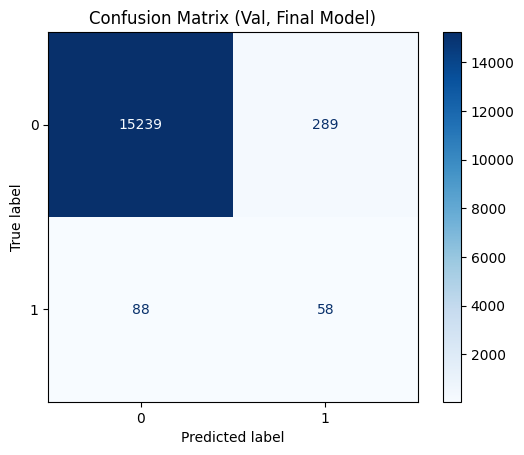

              feature     importance
8      total_discount  687183.619983
1           coupon_id  685950.743155
0         campaign_id  211209.350794
2         customer_id  197403.200438
3           txn_count  175348.151601
7             avg_qty  169313.574114
10       recency_days  158483.415991
6           total_qty  123985.358782
4         total_spent  116111.166924
5           avg_spent  111392.184487
9    coupon_txn_count       0.000000
11  coupon_usage_rate       0.000000


In [53]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Predictions with best threshold
best_preds = (val_probs >= best_thr).astype(int)

print("\nClassification Report:")
print(classification_report(y_val, best_preds, digits=4, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, best_preds))

disp = ConfusionMatrixDisplay(confusion_matrix(y_val, best_preds))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Val, Final Model)")
plt.show()

# Feature importance
fi = pd.DataFrame({
    "feature": X_train_num.columns,
    "importance": lgb_final.feature_importance(importance_type='gain')
}).sort_values("importance", ascending=False)
print(fi.head(15))


Merging various dataset csvs and testing

In [54]:
test = pd.read_csv("../data/coupon_data/test.csv")

test = test.merge(cust_demo_feat, on="customer_id", how="left") \
           .merge(cust_trans_features, on="customer_id", how="left") \
           .merge(campaign_feat, on="campaign_id", how="left") \
           .fillna(0)

# Select numeric and align to model features
X_test_num = test.select_dtypes(include=[np.number]).copy()
for c in meta["features"]:
    if c not in X_test_num.columns:
        X_test_num[c] = 0
X_test_num = X_test_num[meta["features"]]

test["purchase_probability"] = lgb_final.predict(X_test_num, num_iteration=lgb_final.best_iteration)

test[["id","purchase_probability"]].to_csv("../data/coupon_data/submission.csv", index=False)
print("Submission file saved.")


Submission file saved.


Creating lookup tables

In [ ]:

cust_demo_feat.to_csv("src/cust_demo_feat.csv", index=False)
cust_trans_features.to_csv("src/cust_trans_features.csv", index=False)
campaign_feat.to_csv("src/campaign_feat.csv", index=False)


Positive data inputs:

In [55]:
import json

# load best threshold saved earlier
meta = json.load(open("src/model_meta.json"))
best_thr = meta.get("threshold", 0.3)

# filter using that
likely = test[test["purchase_probability"] >= best_thr]

likely_sorted = likely.sort_values("purchase_probability", ascending=False)

top_payloads = [
    {
        "customer_id": int(r["customer_id"]),
        "campaign_id": int(r["campaign_id"]),
        "coupon_id": int(r["coupon_id"]),
        "probability": float(r["purchase_probability"])
    }
    for _, r in likely_sorted.head(100).iterrows()
]

print(json.dumps(top_payloads, indent=2))


[
  {
    "customer_id": 1070,
    "campaign_id": 18,
    "coupon_id": 754,
    "probability": 0.9639418391733812
  },
  {
    "customer_id": 1070,
    "campaign_id": 18,
    "coupon_id": 468,
    "probability": 0.9528812549380946
  },
  {
    "customer_id": 1070,
    "campaign_id": 18,
    "coupon_id": 985,
    "probability": 0.9525963458003543
  },
  {
    "customer_id": 235,
    "campaign_id": 18,
    "coupon_id": 468,
    "probability": 0.9518940356664051
  },
  {
    "customer_id": 1070,
    "campaign_id": 16,
    "coupon_id": 999,
    "probability": 0.9486524566822134
  },
  {
    "customer_id": 1574,
    "campaign_id": 18,
    "coupon_id": 468,
    "probability": 0.9470100680561564
  },
  {
    "customer_id": 235,
    "campaign_id": 17,
    "coupon_id": 703,
    "probability": 0.9459638147756991
  },
  {
    "customer_id": 1574,
    "campaign_id": 18,
    "coupon_id": 533,
    "probability": 0.9458464640344244
  },
  {
    "customer_id": 1574,
    "campaign_id": 18,
    "coupon_

Updating threshold values

In [ ]:
import json
m = json.load(open("src/model_meta.json"))
m["threshold"] = 0.3
json.dump(m, open("src/model_meta.json","w"))



Storing training metrics

In [ ]:
evals_result = {}  # dictionary to store evaluation results

lgb_final = lgb.train(
    params,
    train_set,
    valid_sets=[val_set],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.record_evaluation(evals_result)  # <-- store eval history
    ]
)
# Training Metric (AUC over rounds)
ax = lgb.plot_metric(evals_result, metric="auc")
plt.title("LightGBM Training Metrics (AUC)")
plt.savefig("training_metrics.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ training_metrics.png saved")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[287]	valid_0's auc: 0.925296
✅ training_metrics.png saved


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

results = []

# 1. Logistic Regression
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_num, y_train)
y_pred_proba = log_reg.predict_proba(X_val_num)[:, 1]
y_pred = log_reg.predict(X_val_num)

results.append({
    "Model": "Logistic Regression",
    "AUC": roc_auc_score(y_val, y_pred_proba),
    "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0),
    "F1-Score": f1_score(y_val, y_pred, zero_division=0)
})

# 2. Random Forest
rf = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42)
rf.fit(X_train_num, y_train)
y_pred_proba = rf.predict_proba(X_val_num)[:, 1]
y_pred = rf.predict(X_val_num)

results.append({
    "Model": "Random Forest",
    "AUC": roc_auc_score(y_val, y_pred_proba),
    "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0),
    "F1-Score": f1_score(y_val, y_pred, zero_division=0)
})

# 3. LightGBM (your final model)
y_pred_proba = lgb_final.predict(X_val_num, num_iteration=lgb_final.best_iteration)
y_pred = (y_pred_proba >= 0.5).astype(int)

results.append({
    "Model": "LightGBM",
    "AUC": roc_auc_score(y_val, y_pred_proba),
    "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0),
    "F1-Score": f1_score(y_val, y_pred, zero_division=0)
})

# Create summary table
summary_df = pd.DataFrame(results)
print(summary_df)

# Save to CSV
summary_df.to_csv("model_comparison.csv", index=False)


                 Model       AUC  Precision    Recall  F1-Score
0  Logistic Regression  0.710577   0.016215  0.664384  0.031658
1        Random Forest  0.805812   0.166667  0.095890  0.121739
2             LightGBM  0.925296   0.078309  0.773973  0.142228


Count of Not Redeemed vs Redeemed

In [57]:
import pandas as pd
df = pd.read_csv("C:/Users/yashw/ai-hack/data/train_final.csv")
print(df["redemption_status"].value_counts())
print(df["redemption_status"].value_counts(normalize=True)*100)

redemption_status
0    77640
1      729
Name: count, dtype: int64
redemption_status
0    99.069785
1     0.930215
Name: proportion, dtype: float64
